### Data preparation

In [2]:
import random
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from keras.preprocessing.image import ImageDataGenerator
from keras.utils import to_categorical

In [3]:
train_folder_path = "E:/dogs_vs_cats/train/train"
filenames = os.listdir(train_folder_path)

labels = []
for filename in filenames:
    if filename.split(".")[0] == 'cat':
        labels.append(1)
    else:
        labels.append(0)

df = pd.DataFrame({'filename': filenames,
                   'label': labels})

df.head()

,filename,label
0,cat.0.jpg,1
1,cat.1.jpg,1
2,cat.10.jpg,1
3,cat.100.jpg,1
4,cat.1000.jpg,1


In [4]:
df['label'].value_counts()

label
1    12500
0    12500
Name: count, dtype: int64

In [5]:
df['label'] = df['label'].map({0: 'dog', 1: 'cat'})

In [42]:
train_df, validation_df = train_test_split(df,
                                           test_size=0.2,
                                           random_state=42)
train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

train_size = train_df.shape[0]
validation_size = validation_df.shape[0]

batch_size = 128

In [11]:
width = 64
height = 64

In [12]:
train_datagen = ImageDataGenerator(rotation_range=15,
                                   rescale=1 / 255,
                                   shear_range=0.1,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   width_shift_range=0.1,
                                   height_shift_range=0.1)

train_generator = train_datagen.flow_from_dataframe(train_df,
                                                    train_folder_path,
                                                    x_col='filename',
                                                    y_col='label',
                                                    target_size=(width, height),
                                                    class_mode='categorical')

Found 20000 validated image filenames belonging to 2 classes.


In [13]:
validation_datagen = ImageDataGenerator(rescale=1 / 255)

validation_generator = validation_datagen.flow_from_dataframe(validation_df,
                                                              train_folder_path,
                                                              x_col='filename',
                                                              y_col='label',
                                                              target_size=(width, height),
                                                              class_mode='categorical',
                                                              batch_size=batch_size)

Found 5000 validated image filenames belonging to 2 classes.


In [20]:
example_df = train_df.sample(n=1).reset_index(drop=True)
example_gen = train_datagen.flow_from_dataframe(example_df,
                                                train_folder_path,
                                                x_col='filename',
                                                y_col='label',
                                                target_size=(width, height),
                                                class_mode='categorical')

Found 1 validated image filenames belonging to 1 classes.


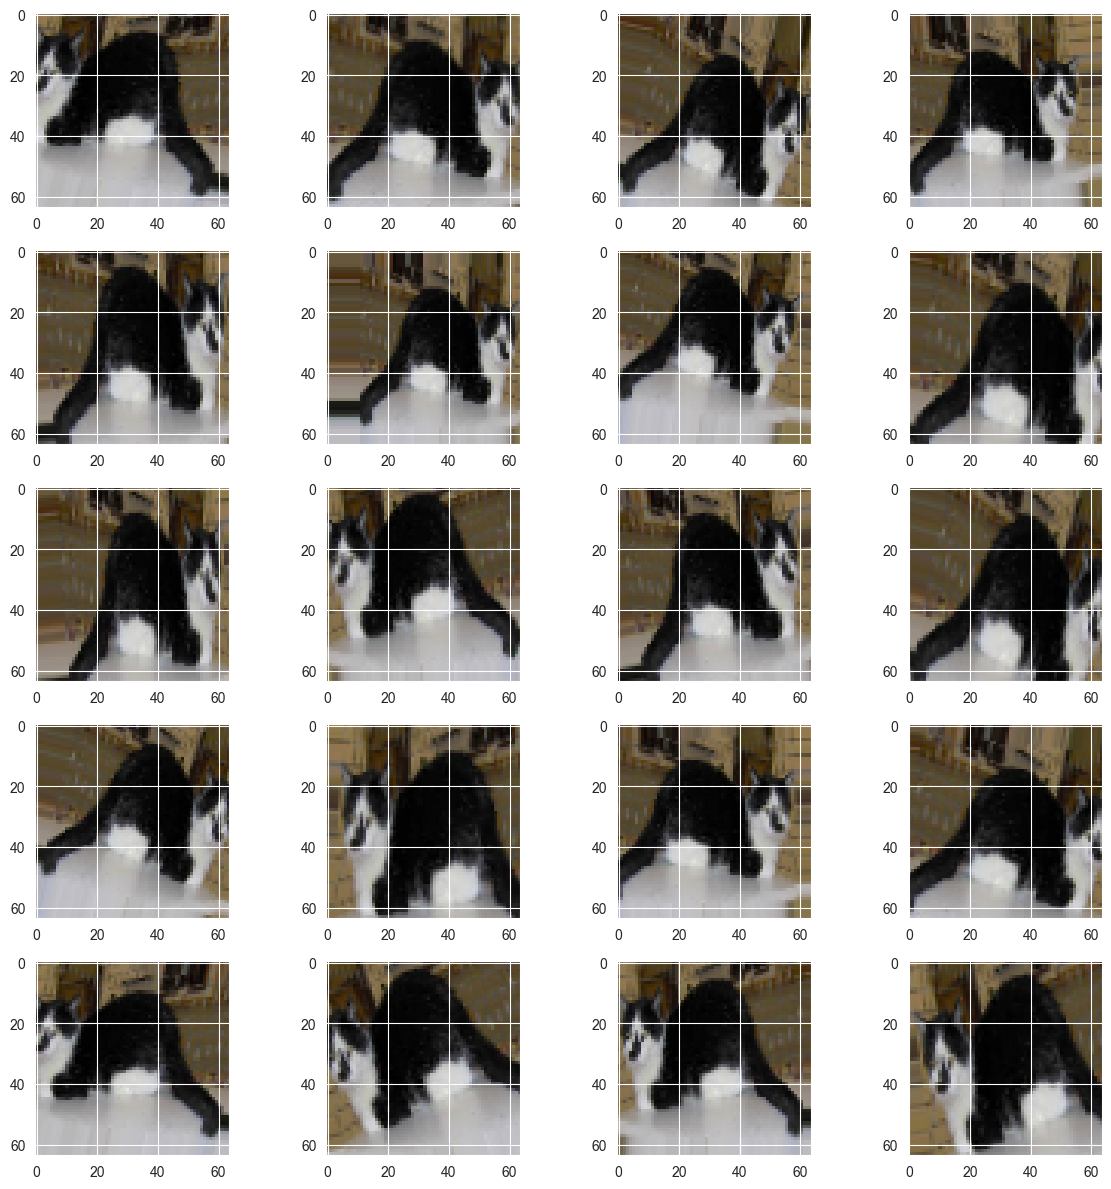

In [21]:
plt.figure(figsize=(12, 12))
for i in range(0, 20):
    plt.subplot(5, 4, i + 1)
    for x_batch, y_batch in example_gen:
        img = x_batch[0]
        plt.imshow(img)
        break
plt.tight_layout()

### Checking GPU support

In [41]:
import sys
import keras
import tensorflow as tf

print(f"tensorflow version: {tf.__version__},\nkeras version: {keras.__version__},\npython version: {sys.version}")
gpu = len(tf.config.list_physical_devices('GPU')) > 0
print(f"\nis gpu available: {gpu}")
print(f"is tensorflow built with cuda: {tf.test.is_built_with_cuda()}")

tensorflow version: 2.10.0,
keras version: 2.10.0,
python version: 3.10.4 (tags/v3.10.4:9d38120, Mar 23 2022, 23:13:41) [MSC v.1929 64 bit (AMD64)]

is gpu available: True
is tensorflow built with cuda: True


### CNN using keras Sequential

In [28]:
import pandas as pd

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [34]:
# width, height = 150, 150
#
# model = Sequential()
#
# # 1st convolutional layer
# model.add(Conv2D(32, (3,3),
#                  activation='relu',
#                  input_shape=(width,height,3)))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size = (2,2)))
# model.add(Dropout(0.25))
#
# # 2nd convolutional layer
# model.add(Conv2D(64, (3,3), activation = 'relu'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size = (2, 2)))
# model.add(Dropout(0.25))
#
# # 3rd convolutional layer
# model.add(Conv2D(128, (3,3), activation = 'relu'))
# model.add(BatchNormalization())
# model.add(MaxPooling2D(pool_size = (2, 2)))
# model.add(Dropout(0.25))
#
# # dense layer
# model.add(Flatten()) # input layer
# model.add(Dense(512, activation = 'relu'))
# model.add(BatchNormalization())
# model.add(Dropout(0.25))
#
# # output layer
# model.add(Dense(2, activation = 'sigmoid'))
#
#
# model.compile(optimizer = 'adam',
#               loss = 'binary_crossentropy',
#               metrics = ['accuracy'])
# model.summary()

gpu_device = '/device:GPU:0'
strategy = tf.distribute.OneDeviceStrategy(device=gpu_device)

with strategy.scope():

    model = Sequential()

    # 1st convolutional layer
    model.add(Conv2D(32, (3, 3), padding='same', input_shape=(width, height, 3)))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 2nd convolutional layer
    model.add(Conv2D(64, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 3rd convolutional layer
    model.add(Conv2D(128, (3, 3), padding='same'))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Dense layer
    model.add(Flatten())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('elu'))
    model.add(Dropout(0.25))

    # Output layer
    model.add(Dense(2, activation='sigmoid'))

    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 64, 64, 32)        896       
                                                                 
 batch_normalization_8 (Batc  (None, 64, 64, 32)       128       
 hNormalization)                                                 
                                                                 
 activation_8 (Activation)   (None, 64, 64, 32)        0         
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 32, 32, 32)       0         
 2D)                                                             
                                                                 
 dropout_8 (Dropout)         (None, 32, 32, 32)        0         
                                                                 
 conv2d_7 (Conv2D)           (None, 32, 32, 64)       

In [35]:
# reducing the learning rate when then accuracy does not increase for 2 steps
earlystop = EarlyStopping(patience=15)

lr_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                 patience=2,
                                 verbose=1,
                                 factor=0.5,
                                 min_lr=0.00001)
callbacks = [earlystop, lr_reduction]

In [43]:
fast = False
epochs = 5 if fast else 30

history = model.fit(train_generator,
                    epochs=epochs,
                    validation_data=validation_generator,
                    validation_steps=validation_size // batch_size,
                    steps_per_epoch=train_size // batch_size,
                    callbacks=callbacks)

Epoch 1/30
 58/156 [==========>...................] - ETA: 27s - loss: 0.6653 - accuracy: 0.6471

KeyboardInterrupt: 

<Axes: >

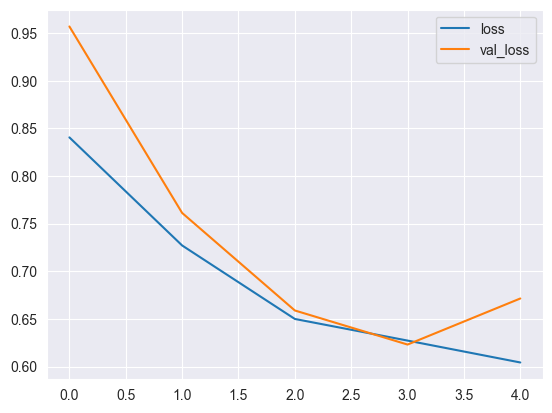

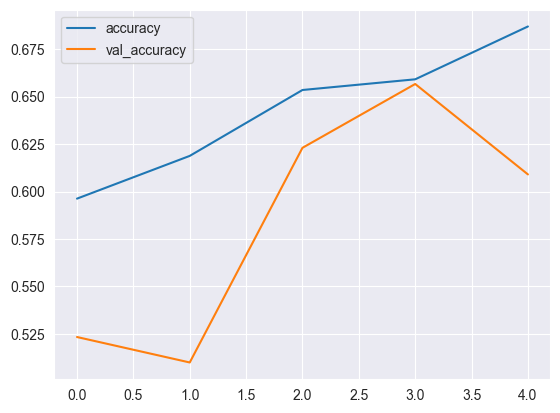

In [26]:
history_frame = pd.DataFrame(history.history)

history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

### Pre-Trained ResNet-50

In [ ]:
from tensorflow.python.keras.applications import ResNet50

resnet50_model = Sequential()
resnet50_model.add(ResNet50(include_top=False,
                            pooling='max',
                            weights='imagenet'))
resnet50_model.add(Dense(2, activation='softmax'))
# ResNet-50 model is already trained, should not be trained
resnet50_model.layers[0].trainable = True

resnet50_model.compile(optimizer='sgd',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

resnet50_model.summary()

### VGG16

In [ ]:
from keras import layers
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Activation, GlobalMaxPooling2D
from keras import optimizers
from keras.applications import VGG16
from keras.models import Model

image_size = 224
input_shape = (image_size, image_size, 3)

epochs = 5
batch_size = 16

pre_trained_model = VGG16(input_shape=input_shape, include_top=False, weights="imagenet")

for layer in pre_trained_model.layers[:15]:
    layer.trainable = False

for layer in pre_trained_model.layers[15:]:
    layer.trainable = True

last_layer = pre_trained_model.get_layer('block5_pool')
last_output = last_layer.output

# Flatten the output layer to 1 dimension
x = GlobalMaxPooling2D()(last_output)
# Add a fully connected layer with 512 hidden units and ReLU activation
x = Dense(512, activation='relu')(x)
# Add a dropout rate of 0.5
x = Dropout(0.5)(x)
# Add a final sigmoid layer for classification
x = layers.Dense(1, activation='sigmoid')(x)

model = Model(pre_trained_model.input, x)

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.SGD(lr=1e-4, momentum=0.9),
              metrics=['accuracy'])

model.summary()